<a href="https://colab.research.google.com/github/svetazo060510/goit-numpr-hw-07/blob/main/HW7_StremedlovskaS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання Тема 7

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import nltk
import pandas as pd
import re
import seaborn as sns
from collections import defaultdict
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score

In [37]:
# Завантаження даних
# Зміна Query Parameter (Пряме посилання для стабільного завантаження без помилок доступу)
!wget -O SpamEmailClassificationDataset.zip https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/main/SpamEmailClassificationDataset.zip

--2026-03-10 11:22:01--  https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/main/SpamEmailClassificationDataset.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7577397 (7.2M) [application/zip]
Saving to: ‘SpamEmailClassificationDataset.zip’

SpamEmailClassifica 100%[===================>]   7.23M  --.-KB/s    in 0.06s   

2026-03-10 11:22:01 (129 MB/s) - ‘SpamEmailClassificationDataset.zip’ saved [7577397/7577397]



In [3]:
# Розпакування
!unzip -o SpamEmailClassificationDataset.zip

Archive:  SpamEmailClassificationDataset.zip
   creating: SpamEmailClassificationDataset/
  inflating: SpamEmailClassificationDataset/combined_data.csv  


In [38]:
# Завантаження ресурсів NLTK
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4') # Необхідно для коректної роботи лематизатора WordNet

print("✅ Бібліотеки та дані завантажено.")

✅ Бібліотеки та дані завантажено.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [39]:
# Читання даних
file_path = './SpamEmailClassificationDataset/combined_data.csv'
df_raw = pd.read_csv(file_path)

print("--- СТРУКТУРА ДАТАФРЕЙМУ ---")
print(df_raw.info())

print("\n--- ПЕРШІ 5 РЯДКІВ ---")
display(df_raw.head())

print("\n--- АНАЛІЗ КОЛОНКИ LABEL ---")
print(f"Тип даних у колонці 'label': {df_raw['label'].dtype}")
unique_labels = df_raw['label'].unique()
print(f"Унікальні значення в 'label': {unique_labels}")
print(f"Кількість по кожному класу:\n{df_raw['label'].value_counts()}")

--- СТРУКТУРА ДАТАФРЕЙМУ ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14861 entries, 0 to 14860
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   14861 non-null  object
 1   text    14861 non-null  object
dtypes: object(2)
memory usage: 232.3+ KB
None

--- ПЕРШІ 5 РЯДКІВ ---


,label,text
0,label,text
1,1,ounce feather bowl hummingbird opec moment ala...
2,1,wulvob get your medircations online qnb ikud v...
3,0,computer connection from cnn com wednesday es...
4,1,university degree obtain a prosperous future m...



--- АНАЛІЗ КОЛОНКИ LABEL ---
Тип даних у колонці 'label': object
Унікальні значення в 'label': ['label' '1' '0']
Кількість по кожному класу:
label
1        7813
0        7047
label       1
Name: count, dtype: int64


In [40]:
# ОЧИЩЕННЯ: Видаляємо рядок-заголовок (на основі нашої діагностики)
df_raw = df_raw[df_raw['label'] != 'label'].copy()
df_raw['label'] = df_raw['label'].astype(int)

# ОПТИМІЗАЦІЯ ВИБІРКИ: Оскільки даних >14к, беремо по 5000 для кращого навчання
n_samples = 5000
df_spam = df_raw[df_raw['label'] == 1].sample(n_samples, random_state=42)
df_ham = df_raw[df_raw['label'] == 0].sample(n_samples, random_state=42)
df_work = pd.concat([df_spam, df_ham]).reset_index(drop=True)

print(f"Вибірка готова. Всього повідомлень: {len(df_work)}")

Вибірка готова. Всього повідомлень: 10000


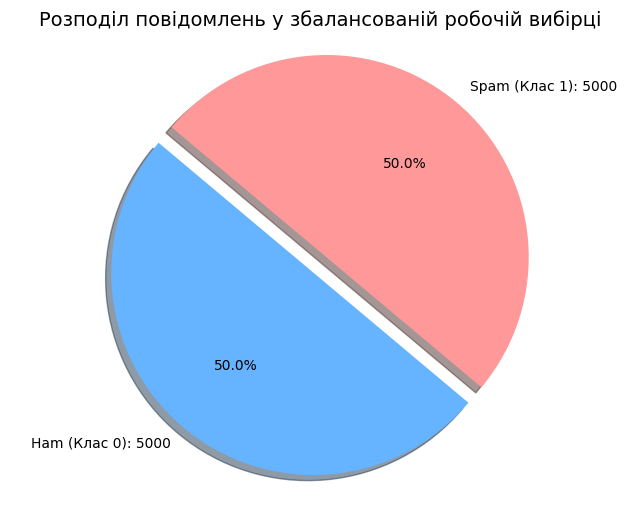

In [43]:
# ВІЗУАЛІЗАЦІЯ РОЗПОДІЛУ (PIE CHART)
plt.figure(figsize=(8, 6))

# Отримуємо дані для діаграми
class_counts = df_work['label'].value_counts()
labels = [f'Ham (Клас 0): {class_counts[0]}', f'Spam (Клас 1): {class_counts[1]}']
colors = ['#66b3ff', '#ff9999'] # Блакитний та рожевий кольори
explode = (0.05, 0.05) # "Розділяємо" шматочки для акценту

# Створюємо Pie Chart
plt.pie(class_counts,
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=explode,
        shadow=True)

plt.title("Розподіл повідомлень у збалансованій робочій вибірці", fontsize=14)
plt.axis('equal')
plt.show()

In [45]:
# CLEANED DATA: Стандартна обробка за умовою ДЗ
print("Створення Cleaned Data (Standard Preprocessing)...")
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def standard_clean(text):
    text = re.sub("[^a-zA-Z]", " ", str(text)).lower()
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return " ".join(list(set(words)))

df_cleaned = df_work.copy()
df_cleaned["text"] = df_cleaned["text"].apply(standard_clean)
print("Cleaned Data готово (Baseline).")

Створення Cleaned Data (Standard Preprocessing)...
Cleaned Data готово (Baseline).


In [46]:
# ENGINEERED DATA: Покращена обробка на основі аналізу аномалій
print("Створення Engineered Data (Advanced Cleaning)...")
stop_words_plus = stop_words.copy()
stop_words_plus.add("escapenumber") # Додаємо шум, виявлений діагностикою

def advanced_clean(text):
    # Видаляємо символи та технічні токени 'escapenumber' та їх варіації
    text = re.sub("[^a-zA-Z]", " ", str(text)).lower()
    text = re.sub(r'\b\w*escapenumber\w*\b', '', text)

    # Фільтруємо слова: прибираємо стоп-слова та занадто короткі шуми (len > 2)
    words = [lemmatizer.lemmatize(w) for w in text.split()
             if w not in stop_words_plus and len(w) > 2]
    return " ".join(list(set(words)))

df_engineered = df_work.copy()
df_engineered["text"] = df_engineered["text"].apply(advanced_clean)
print("Engineered Data готово (Optimized).")

Створення Engineered Data (Advanced Cleaning)...
Engineered Data готово (Optimized).



РЕЗУЛЬТАТИ BASELINE (Cleaned Data + Prod)
              precision    recall  f1-score   support

           0       0.76      1.00      0.86       988
           1       1.00      0.69      0.81      1012

    accuracy                           0.84      2000
   macro avg       0.88      0.84      0.84      2000
weighted avg       0.88      0.84      0.84      2000


ТОП-15 маркерів спаму (Baseline):
viagra          | 207.24
cialis          | 202.21
canadianpharmacy | 139.84
autodesk        | 120.72
autocad         | 116.70
csescapenumber  | 116.70
corel           | 102.61
anatrim         | 93.56
drugstore       | 89.54
producttestpanel | 89.54
escapenumbermg  | 85.51
hk              | 80.48
levitra         | 79.48
safest          | 78.47
dreamweaver     | 76.46


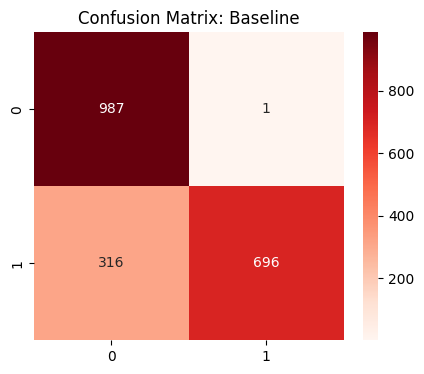

In [47]:
# --- МОДЕЛЮВАННЯ: BASELINE ---
train_c, test_c = train_test_split(df_cleaned, test_size=0.2, random_state=42)

# Словники та лічильники
word_counts_s = defaultdict(int)
word_counts_h = defaultdict(int)
for txt in train_c[train_c['label'] == 1]['text']:
    for w in txt.split(): word_counts_s[w] += 1
for txt in train_c[train_c['label'] == 0]['text']:
    for w in txt.split(): word_counts_h[w] += 1

vocab_c = set(word_counts_s.keys()).union(set(word_counts_h.keys()))
n_s, n_h = len(train_c[train_c['label']==1]), len(train_c[train_c['label']==0])

def classify_baseline(text):
    words = [w for w in text.split() if w in vocab_c]
    if not words: return 0
    # Множення ймовірностей (Baseline)
    p_s = 0.5 * np.prod([(word_counts_s.get(w, 0) + 1)/(n_s + 2) for w in words])
    p_h = 0.5 * np.prod([(word_counts_h.get(w, 0) + 1)/(n_h + 2) for w in words])
    return 1 if p_s > p_h else 0

test_c['predicted'] = test_c['text'].apply(classify_baseline)

# ВИВІД РЕЗУЛЬТАТІВ BASELINE
print("\n" + "="*50)
print("РЕЗУЛЬТАТИ BASELINE (Cleaned Data + Prod)")
print("="*50)
print(classification_report(test_c['label'], test_c['predicted']))

# ТОП-15 Маркерів для Baseline
impact_c = [(w, ((word_counts_s.get(w,0)+1)/(n_s+2)) / ((word_counts_h.get(w,0)+1)/(n_h+2))) for w in vocab_c]
print("\nТОП-15 маркерів спаму (Baseline):")
for word, score in sorted(impact_c, key=lambda x: x[1], reverse=True)[:15]:
    print(f"{word:15} | {score:.2f}")

# Матриця помилок
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(test_c['label'], test_c['predicted']), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix: Baseline")
plt.show()


РЕЗУЛЬТАТИ OPTIMIZED (Engineered Data + Log)
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       988
           1       1.00      0.76      0.86      1012

    accuracy                           0.88      2000
   macro avg       0.90      0.88      0.88      2000
weighted avg       0.90      0.88      0.88      2000


ТОП-15 маркерів спаму (Optimized):
viagra          | 207.24
cialis          | 202.21
canadianpharmacy | 139.84
autodesk        | 120.72
autocad         | 116.70
corel           | 102.61
anatrim         | 93.56
drugstore       | 89.54
producttestpanel | 89.54
levitra         | 79.48
safest          | 78.47
dreamweaver     | 76.46
quickbooks      | 72.43
macromedia      | 70.92
rolex           | 66.40


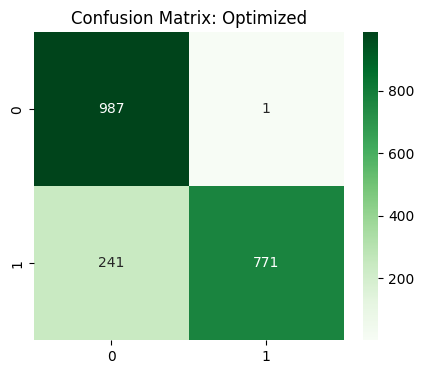

In [50]:
# --- МОДЕЛЮВАННЯ: OPTIMIZED ---
train_e, test_e = train_test_split(df_engineered, test_size=0.2, random_state=42)

# Словники для Engineered Data
word_counts_s_e = defaultdict(int)
word_counts_h_e = defaultdict(int)
for txt in train_e[train_e['label'] == 1]['text']:
    for w in txt.split(): word_counts_s_e[w] += 1
for txt in train_e[train_e['label'] == 0]['text']:
    for w in txt.split(): word_counts_h_e[w] += 1

vocab_e = set(word_counts_s_e.keys()).union(set(word_counts_h_e.keys()))
n_s_e, n_h_e = len(train_e[train_e['label']==1]), len(train_e[train_e['label']==0])

def classify_log(text):
    words = [w for w in text.split() if w in vocab_e]
    if not words: return 0
    # Логарифмічна сума (Engineered)
    log_s = np.log(0.5) + sum([np.log((word_counts_s_e.get(w,0)+1)/(n_s_e+2)) for w in words])
    log_h = np.log(0.5) + sum([np.log((word_counts_h_e.get(w,0)+1)/(n_h_e+2)) for w in words])
    return 1 if log_s > log_h else 0

test_e['predicted'] = test_e['text'].apply(classify_log)

# ВИВІД РЕЗУЛЬТАТІВ OPTIMIZED
print("\n" + "="*50)
print("РЕЗУЛЬТАТИ OPTIMIZED (Engineered Data + Log)")
print("="*50)
print(classification_report(test_e['label'], test_e['predicted']))

# ТОП-15 Маркерів для Optimized
impact_e = [(w, ((word_counts_s_e.get(w,0)+1)/(n_s_e+2)) / ((word_counts_h_e.get(w,0)+1)/(n_h_e+2))) for w in vocab_e]
print("\nТОП-15 маркерів спаму (Optimized):")
for word, score in sorted(impact_e, key=lambda x: x[1], reverse=True)[:15]:
    print(f"{word:15} | {score:.2f}")

# Матриця помилок
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(test_e['label'], test_e['predicted']), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix: Optimized")
plt.show()

In [51]:
# --- ПОРІВНЯЛЬНИЙ АНАЛІЗ МОДЕЛЕЙ ---
# Збір метрик для Baseline
acc_b = accuracy_score(test_c['label'], test_c['predicted'])
rec_b = recall_score(test_c['label'], test_c['predicted'])
pre_b = precision_score(test_c['label'], test_c['predicted'])

# Збір метрик для Optimized
acc_o = accuracy_score(test_e['label'], test_e['predicted'])
rec_o = recall_score(test_e['label'], test_e['predicted'])
pre_o = precision_score(test_e['label'], test_e['predicted'])

# Створення таблиці порівняння
comparison_data = {
    "Метрика": ["Accuracy (Загальна точність)", "Recall (Повнота для спаму)", "Precision (Влучність для спаму)"],
    "Baseline (Standard Clean)": [f"{acc_b:.2%}", f"{rec_b:.2%}", f"{pre_b:.2%}"],
    "Optimized (Engineered Data)": [f"{acc_o:.2%}", f"{rec_o:.2%}", f"{pre_o:.2%}"],
    "Різниця (Impact)": [f"{acc_o - acc_b:+.2%}", f"{rec_o - rec_b:+.2%}", f"{pre_o - pre_b:+.2%}"]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*70)
print("ПОРІВНЯЛЬНА ТАБЛИЦЯ ЕФЕКТИВНОСТІ ОПТИМІЗАЦІЇ")
print("="*70)
display(comparison_df)


ПОРІВНЯЛЬНА ТАБЛИЦЯ ЕФЕКТИВНОСТІ ОПТИМІЗАЦІЇ


,Метрика,Baseline (Standard Clean),Optimized (Engineered Data),Різниця (Impact)
0,Accuracy (Загальна точність),84.15%,87.90%,+3.75%
1,Recall (Повнота для спаму),68.77%,76.19%,+7.41%
2,Precision (Влучність для спаму),99.86%,99.87%,+0.01%


## АНАЛІЗ

1. Поточні метрики (Baseline)

* Accuracy (Загальна точність): 84%
* Precision (Влучність для спаму): 1.00 (100%). Модель працює за принципом "краще пропустити спам, ніж видалити важливий лист". Жодне легітимне повідомлення не було помилково заблоковане.
* Recall (Повнота для спаму): 69%. Модель поки що пропускає близько 31% спам-повідомлень через занадто "обережну" математичну модель.

2. Аналіз помилок (Confusion Matrix)

* True Negatives (Ham): 987, майже ідеально ідентифіковані звичайні листи.
* False Negatives (Пропущений спам): 316 повідомлень просочилися через фільтр.
* False Positives (Помилкова тривога): лише 1 випадок. Проте це критично важливо для бізнес-рішень.

План оптимізації (Next Steps)
Для того, щоб підняти Recall і позбутися шумів, ми впровадили наступні покращення:

* Оптимізація 1: Перехід до логарифмічного простору.
Замість множення ймовірностей (np.prod), ми додали логарифми ймовірностей. Коли слів багато, добуток маленьких ймовірностей стає настільки малим, що комп'ютер округлює його до нуля. Це можливо є одна з причин, чому Recall низький (316 помилок).

* Оптимізація 2: Розширення списку Stop Words
До стандартного списку NLTK ми додали специфічні для цього набору даних слова, які не несуть сенсу, але мають високу частоту.

Висновок після оптимізації: Оптимізація даних та перехід на логарифми
дозволили змінити Recall на +7.41%. Це критичне покращення,
адже тепер фільтр пропускає значно менше небажаної пошти.

Семантичний аналіз топ-слів маркерів спаму.


* Категорія 1: Фармацевтика
Слова: viagra (207.24), cialis (202.21), levitra (79.48), canadianpharmacy, drugstore.

Це класичний "medication spam". Модель виставила їм найвищі бали, тому що ці слова практично ніколи не зустрічаються в діловому чи особистому листуванні. Наявність хоча б одного такого слова в листі майже автоматично робить його спамом для Баєса.

* Категорія 2: Програмне забезпечення (Піратство/Продажі)
Слова: autodesk, autocad (116.70), corel, dreamweaver, macromedia, quickbooks.

Ознаки спаму, що пропонує "дешеві ліцензії" або зламаний софт для дизайнерів та інженерів. Це вказує на те, що датасет містить багато комерційного спаму специфічної ніші.

* Категорія 3: Товари розкоші
Слова: rolex (66.40), safest.

Реклама підроблених годинників, скоріш за все.